In [ ]:
import pandas as pd
import numpy as np

df = pd.read_excel(r'G:\pgcb-forecasting\data\PGCB_date_power_demand.xlsx')
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.groupby('datetime', as_index=True).mean(numeric_only=True).sort_index()

target_col = 'generation_mw'
df = df.resample('h').mean()


df.loc[(df[target_col] > 25000) | (df[target_col] <= 0), target_col] = np.nan

df[target_col] = df[target_col].interpolate(limit=6).ffill().bfill()

df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['lag_1'] = df[target_col].shift(1)
df['lag_24'] = df[target_col].shift(24)
df['lag_168'] = df[target_col].shift(168)
df['rolling_mean_24'] = df[target_col].shift(1).rolling(24).mean()

df = df.dropna(subset=['lag_1', 'lag_24', 'lag_168', 'rolling_mean_24'])
print(df.shape)

(88933, 20)


In [6]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

split_idx = int(len(df) * 0.8)
train_df, test_df = df.iloc[:split_idx], df.iloc[split_idx:]

features = ['hour', 'dayofweek', 'month', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24']
X_train, y_train = train_df[features], train_df[target_col]
X_test, y_test = test_df[features], test_df[target_col]

xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

mae = mean_absolute_error(y_test, xgb_preds)
rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
mask = y_test != 0
mape = np.mean(np.abs((y_test[mask] - xgb_preds[mask]) / y_test[mask])) * 100

print(f"XGBoost Results -> MAE: {mae:.2f} MW, RMSE: {rmse:.2f} MW, MAPE: {mape:.2f}%")

XGBoost Results -> MAE: 246.88 MW, RMSE: 363.08 MW, MAPE: 2.25%


In [7]:
#LSTM model
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

torch.manual_seed(42)
np.random.seed(42)

WINDOW = 48  # use the past 48 hours to predict the next hour

series = df[target_col].values.astype('float32')
split_idx = int(len(df) * 0.8)
train_series = series[:split_idx]
test_series = series[split_idx:]

# Scale using ONLY train stats (never let test data leak into scaling)
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_series.reshape(-1, 1)).flatten()
test_scaled = scaler.transform(test_series.reshape(-1, 1)).flatten()

def make_windows(arr, window):
    X, y = [], []
    for i in range(len(arr) - window):
        X.append(arr[i:i+window])
        y.append(arr[i+window])
    return np.array(X), np.array(y)

X_train_seq, y_train_seq = make_windows(train_scaled, WINDOW)
# prepend the tail of train so the first test predictions have real history
combined = np.concatenate([train_scaled[-WINDOW:], test_scaled])
X_test_seq, y_test_seq = make_windows(combined, WINDOW)

X_train_t = torch.tensor(X_train_seq).unsqueeze(-1)
y_train_t = torch.tensor(y_train_seq).unsqueeze(-1)
X_test_t = torch.tensor(X_test_seq).unsqueeze(-1)

class LSTMModel(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, num_layers=2,
                             batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])   # use last timestep's output

model = LSTMModel()
opt = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

batch_size = 256
n_epochs = 15   # bump to 20-30 if you have time; returns flatten out after ~15

for epoch in range(n_epochs):
    perm = torch.randperm(X_train_t.shape[0])
    total_loss = 0
    for i in range(0, len(perm), batch_size):
        idx = perm[i:i+batch_size]
        xb, yb = X_train_t[idx], y_train_t[idx]
        opt.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()
        total_loss += loss.item() * len(idx)
    print(f"epoch {epoch+1}/{n_epochs}, loss {total_loss/len(perm):.6f}")

epoch 1/15, loss 0.018244
epoch 2/15, loss 0.003959
epoch 3/15, loss 0.002298
epoch 4/15, loss 0.001562
epoch 5/15, loss 0.001100
epoch 6/15, loss 0.000886
epoch 7/15, loss 0.000770
epoch 8/15, loss 0.000727
epoch 9/15, loss 0.000698
epoch 10/15, loss 0.000678
epoch 11/15, loss 0.000630
epoch 12/15, loss 0.000620
epoch 13/15, loss 0.000616
epoch 14/15, loss 0.000604
epoch 15/15, loss 0.000586


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

model.eval()
with torch.no_grad():
    preds_scaled = model(X_test_t).numpy().flatten()

lstm_preds = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
lstm_actual = scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

mae_lstm = mean_absolute_error(lstm_actual, lstm_preds)
rmse_lstm = np.sqrt(mean_squared_error(lstm_actual, lstm_preds))
mask = lstm_actual != 0
mape_lstm = np.mean(np.abs((lstm_actual[mask] - lstm_preds[mask]) / lstm_actual[mask])) * 100

print(f"LSTM Results -> MAE: {mae_lstm:.2f} MW, RMSE: {rmse_lstm:.2f} MW, MAPE: {mape_lstm:.2f}%")

LSTM Results -> MAE: 298.80 MW, RMSE: 414.85 MW, MAPE: 2.72%


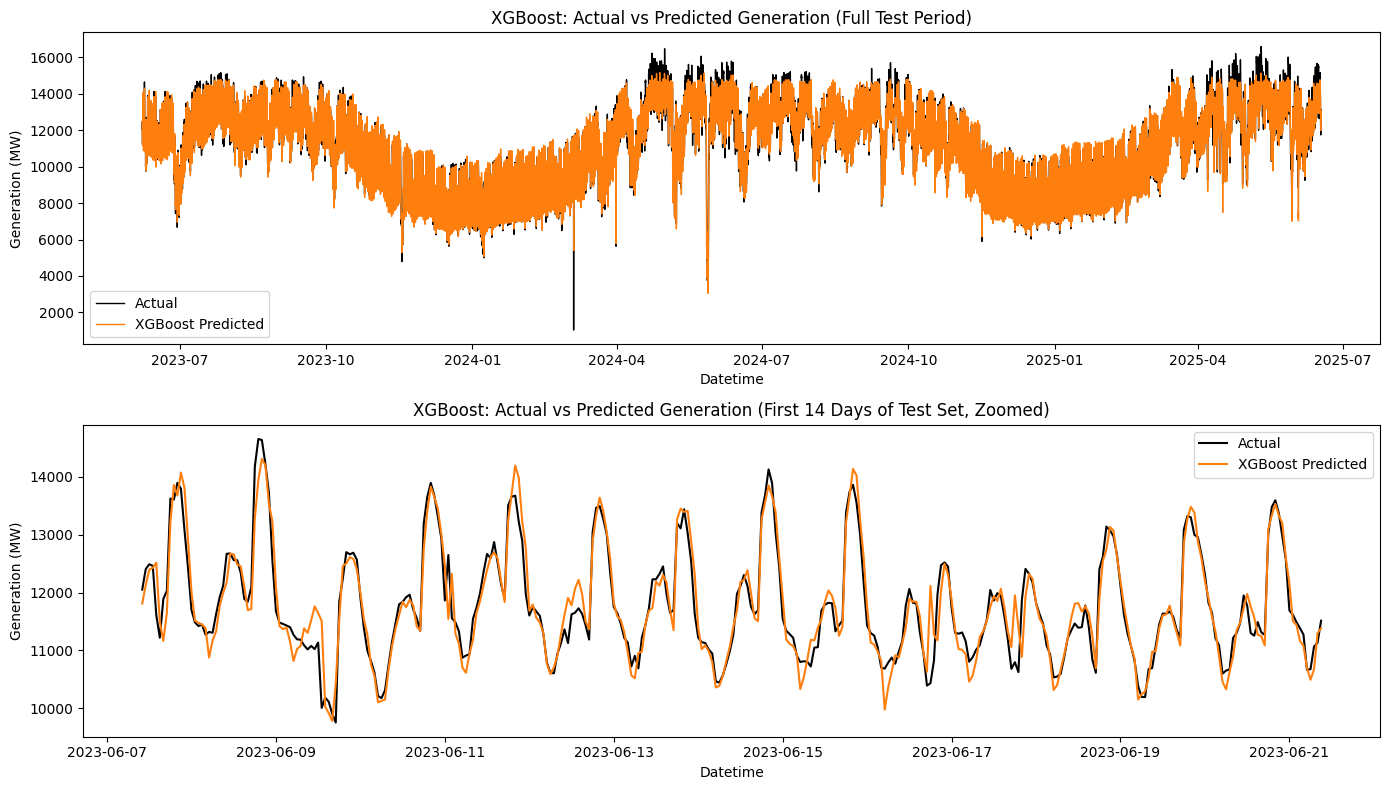

In [9]:
import matplotlib.pyplot as plt

test_index = test_df.index  # datetime index for the test period

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full test period
axes[0].plot(test_index, y_test, label='Actual', color='black', linewidth=1)
axes[0].plot(test_index, xgb_preds, label='XGBoost Predicted', color='tab:orange', linewidth=1)
axes[0].set_title('XGBoost: Actual vs Predicted Generation (Full Test Period)')
axes[0].set_xlabel('Datetime')
axes[0].set_ylabel('Generation (MW)')
axes[0].legend()

# Zoomed-in: first 14 days of test set (easier to actually see the fit)
zoom_n = 24 * 14
axes[1].plot(test_index[:zoom_n], y_test[:zoom_n], label='Actual', color='black', linewidth=1.5)
axes[1].plot(test_index[:zoom_n], xgb_preds[:zoom_n], label='XGBoost Predicted', color='tab:orange', linewidth=1.5)
axes[1].set_title('XGBoost: Actual vs Predicted Generation (First 14 Days of Test Set, Zoomed)')
axes[1].set_xlabel('Datetime')
axes[1].set_ylabel('Generation (MW)')
axes[1].legend()

plt.tight_layout()
plt.savefig('xgboost_actual_vs_predicted.png', dpi=150)
plt.show()

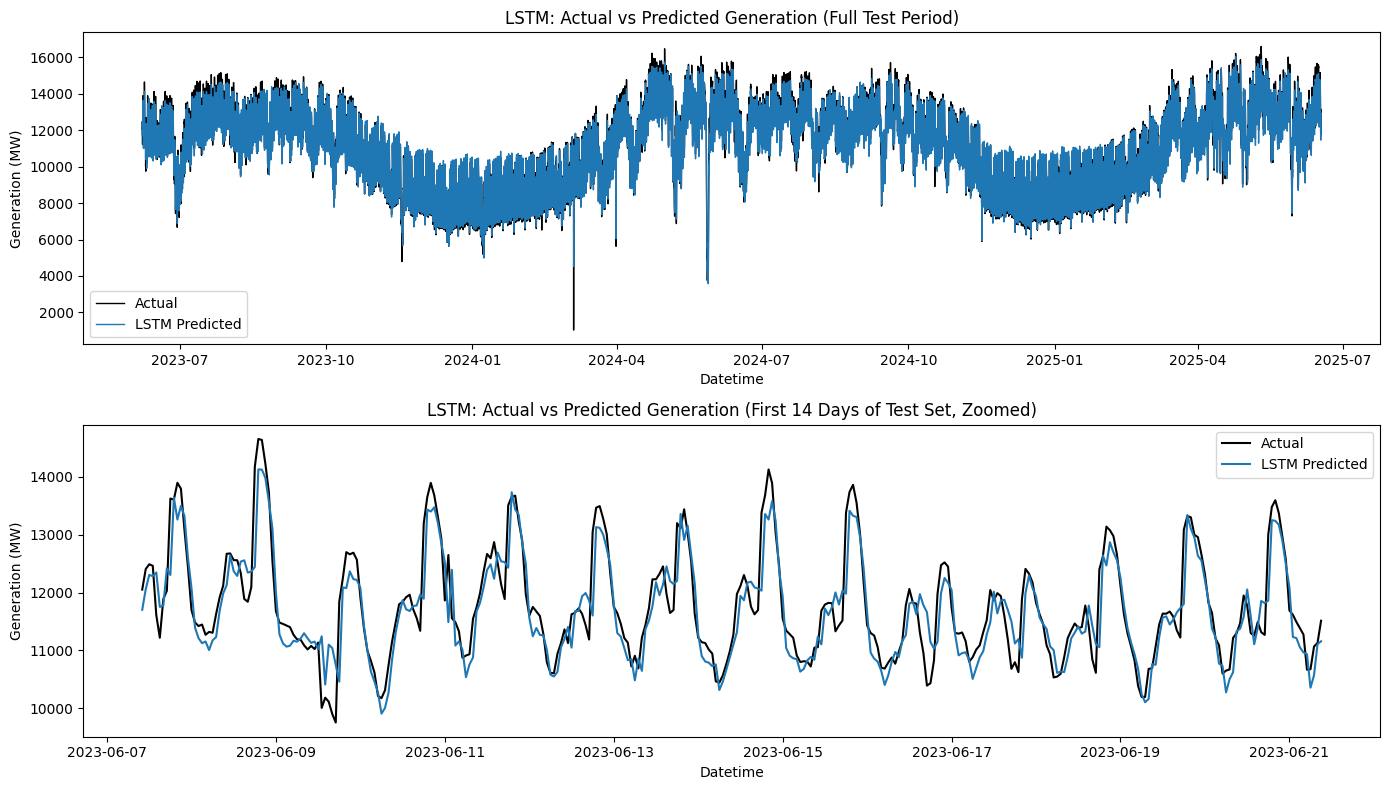

In [10]:
# Datetime index aligned to the LSTM's test predictions
test_index_lstm = df.index[split_idx:]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(test_index_lstm, lstm_actual, label='Actual', color='black', linewidth=1)
axes[0].plot(test_index_lstm, lstm_preds, label='LSTM Predicted', color='tab:blue', linewidth=1)
axes[0].set_title('LSTM: Actual vs Predicted Generation (Full Test Period)')
axes[0].set_xlabel('Datetime')
axes[0].set_ylabel('Generation (MW)')
axes[0].legend()

zoom_n = 24 * 14
axes[1].plot(test_index_lstm[:zoom_n], lstm_actual[:zoom_n], label='Actual', color='black', linewidth=1.5)
axes[1].plot(test_index_lstm[:zoom_n], lstm_preds[:zoom_n], label='LSTM Predicted', color='tab:blue', linewidth=1.5)
axes[1].set_title('LSTM: Actual vs Predicted Generation (First 14 Days of Test Set, Zoomed)')
axes[1].set_xlabel('Datetime')
axes[1].set_ylabel('Generation (MW)')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_actual_vs_predicted.png', dpi=150)
plt.show()

In [11]:
import numpy as np
import pandas as pd
import torch

FUTURE_HOURS = 72  # how far into the future to forecast beyond your last data point

xgb_resid_std = np.std(y_test - xgb_preds)
lstm_resid_std = np.std(lstm_actual - lstm_preds)

# ---- Recursive future forecast: XGBoost ----
hist_vals = list(df[target_col].values)
future_index = pd.date_range(df.index[-1] + pd.Timedelta(hours=1), periods=FUTURE_HOURS, freq='h')
xgb_future = []
for ts in future_index:
    row = pd.DataFrame([{
        'hour': ts.hour, 'dayofweek': ts.dayofweek, 'month': ts.month,
        'lag_1': hist_vals[-1], 'lag_24': hist_vals[-24], 'lag_168': hist_vals[-168],
        'rolling_mean_24': np.mean(hist_vals[-24:])
    }])[features]
    pred = float(xgb.predict(row)[0])
    xgb_future.append(pred)
    hist_vals.append(pred)

# ---- Recursive future forecast: LSTM ----
window_vals = list(scaler.transform(df[target_col].values[-WINDOW:].reshape(-1, 1)).flatten())
lstm_future_scaled = []
model.eval()
with torch.no_grad():
    for _ in range(FUTURE_HOURS):
        x_in = torch.tensor(np.array(window_vals[-WINDOW:], dtype='float32')).reshape(1, WINDOW, 1)
        p = model(x_in).item()
        lstm_future_scaled.append(p)
        window_vals.append(p)
lstm_future = scaler.inverse_transform(np.array(lstm_future_scaled).reshape(-1, 1)).flatten()

# ---- Assemble one combined export table ----
hist_export = pd.DataFrame({'datetime': df.index, 'actual': df[target_col].values})
for c in ['xgb_pred', 'lstm_pred', 'xgb_lower', 'xgb_upper', 'lstm_lower', 'lstm_upper']:
    hist_export[c] = np.nan
hist_export = hist_export.set_index('datetime')

hist_export.loc[test_df.index, 'xgb_pred'] = xgb_preds
hist_export.loc[test_df.index, 'xgb_lower'] = xgb_preds - 1.96 * xgb_resid_std
hist_export.loc[test_df.index, 'xgb_upper'] = xgb_preds + 1.96 * xgb_resid_std
hist_export.loc[test_index_lstm, 'lstm_pred'] = lstm_preds
hist_export.loc[test_index_lstm, 'lstm_lower'] = lstm_preds - 1.96 * lstm_resid_std
hist_export.loc[test_index_lstm, 'lstm_upper'] = lstm_preds + 1.96 * lstm_resid_std

future_export = pd.DataFrame({
    'datetime': future_index, 'actual': np.nan,
    'xgb_pred': xgb_future, 'lstm_pred': lstm_future
}).set_index('datetime')
future_export['xgb_lower'] = future_export['xgb_pred'] - 1.96 * xgb_resid_std
future_export['xgb_upper'] = future_export['xgb_pred'] + 1.96 * xgb_resid_std
future_export['lstm_lower'] = future_export['lstm_pred'] - 1.96 * lstm_resid_std
future_export['lstm_upper'] = future_export['lstm_pred'] + 1.96 * lstm_resid_std

final_export = pd.concat([hist_export, future_export]).reset_index().rename(columns={'index': 'datetime'})

metrics = pd.DataFrame({
    'model': ['XGBoost', 'LSTM'],
    'MAE': [mae, mae_lstm], 'RMSE': [rmse, rmse_lstm], 'MAPE': [mape, mape_lstm]
})

final_export.to_csv('dashboard_data.csv', index=False)
metrics.to_csv('dashboard_metrics.csv', index=False)
print(final_export.shape, "saved")

(89005, 8) saved
